# Data Analysis (Classification)

## Download SUSY Dataset
The information about the dataset can be found at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). We'll start with the [SUSY Dataset](https://archive.ics.uci.edu/ml/datasets/SUSY).


### Download
In a terminal, download the data directly from the source and then decompress it. For example:

The information about the dataset can be found at the UCI Machine Learning Repository. We'll start with the SUSY Dataset.

Download
In a terminal, download the data directly from the source and then decompress it. For example:

* To download:
    * On Mac OS:
    `curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`

    * In linux:
    `wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz`

* To uncompress:
`gunzip SUSY.csv.gz`

In [1]:
!curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  879M    0  879M    0     0  17.6M      0 --:--:--  0:00:49 --:--:-- 25.6M  16.1M      0 --:--:--  0:00:17 --:--:-- 24.9M --:--:--  0:00:25 --:--:-- 17.7M--:--:-- 18.9M  0     0  17.2M      0 --:--:--  0:00:47 --:--:-- 25.6M


In [2]:
!gunzip SUSY.csv.gz

In [3]:
ls-lh

total 4670328
-rw-r--r--@ 1 christian  staff   129K Jul 11 20:13 Christian_Herrera_Mini_Project.ipynb
drwxr-xr-x  5 christian  staff   160B Jun  9 16:50 Lab 1/
drwxr-xr-x@ 6 christian  staff   192B Jun 23 13:19 Lab 2/
drwxr-xr-x@ 4 christian  staff   128B Jun 30 13:51 Lab 3/
drwxr-xr-x  8 christian  staff   256B Jul  4 04:09 Lab 4/
drwxr-xr-x@ 3 christian  staff    96B Jul  9 14:19 Lab 5/
drwxr-xr-x@ 4 christian  staff   128B Jul 16 14:43 Lab 6/
-rw-r--r--@ 1 christian  staff   464B Jun  9 16:50 Lecture 1.ipynb
-rw-r--r--@ 1 christian  staff    59K Jul  4 04:09 Python_II_2026summer_Week5Lecture1.ipynb
-rw-r--r--@ 1 christian  staff    13K Jul  4 04:09 Python_II_2026summer_Week5Lecture2.ipynb
-rw-r--r--@ 1 christian  staff    12K Jul 21 13:24 Python_II_2026summer_Week7.ipynb
-rw-r--r--@ 1 christian  staff   2.2G Jul 21 13:24 SUSY.csv
-rw-r--r--@ 1 christian  staff   8.0K Jun  9 16:50 W1L2.ipynb
-rw-r--r--@ 1 christian  staff   901B Jun  9 16:51 W2L1.ipynb
-rw-r--r--@ 1 christian  staff 

In [4]:
!wc -l SUSY.csv # prints the number of the lines in the file(each line usually corresponds to one record or row.)

 5000000 SUSY.csv


In [5]:
!head -500000 SUSY.csv > SUSY-small.csv

In [6]:
!wc -l SUSY-small.csv

  500000 SUSY-small.csv


In [7]:
filename="SUSY-small.csv"
!head -5 "SUSY-small.csv"

0.000000000000000000e+00,9.728614687919616699e-01,6.538545489311218262e-01,1.176224589347839355e+00,1.157156467437744141e+00,-1.739873170852661133e+00,-8.743090629577636719e-01,5.677649974822998047e-01,-1.750000417232513428e-01,8.100607395172119141e-01,-2.525521218776702881e-01,1.921887040138244629e+00,8.896374106407165527e-01,4.107718467712402344e-01,1.145620822906494141e+00,1.932632088661193848e+00,9.944640994071960449e-01,1.367815494537353516e+00,4.071449860930442810e-02
1.000000000000000000e+00,1.667973041534423828e+00,6.419061869382858276e-02,-1.225171446800231934e+00,5.061022043228149414e-01,-3.389389812946319580e-01,1.672542810440063477e+00,3.475464344024658203e+00,-1.219136357307434082e+00,1.295456290245056152e-02,3.775173664093017578e+00,1.045977115631103516e+00,5.680512785911560059e-01,4.819284379482269287e-01,0.000000000000000000e+00,4.484102725982666016e-01,2.053557634353637695e-01,1.321893453598022461e+00,3.775840103626251221e-01
1.000000000000000000e+00,4.4483992457389831

In [8]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi",
          "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2",
          "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))
FeatureNames

['cos_theta_r1',
 'M_R',
 'axial_MET',
 'R',
 'dPhi_r_b',
 'S_R',
 'MET_rel',
 'M_TR_2',
 'MT2',
 'M_Delta_R']

Now we can read teh data into a pandas dataframe

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [10]:
filename="SUSY-small.csv"
df=pd.read_csv(filename, dtype="float64", names=VarNames)

In [11]:
df

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,0.0,0.719035,1.091879,0.291540,1.205962,-1.599117,-1.139445,0.424546,1.154849,0.637185,-0.091178,1.972156,0.697028,0.313636,0.988602,1.981573,0.744828,1.095080,0.006546
499996,1.0,0.910016,-0.364544,-0.777120,0.543648,-0.910632,-1.723707,2.864673,1.458272,2.176558,-0.590911,0.673695,1.662140,2.189362,1.195041,0.910815,1.181893,1.252362,0.826035
499997,1.0,0.842954,0.332476,-1.048564,1.347989,0.320496,-0.666358,0.450433,-0.411872,0.293407,0.630491,0.859920,0.403371,0.416258,0.591989,0.372003,0.716788,0.366991,0.265798
499998,0.0,1.370760,-1.162912,0.893499,2.118091,1.248496,-0.887211,0.164659,0.316840,0.215165,0.280418,3.087083,0.526929,0.151467,0.308067,3.098183,0.233042,0.876216,0.000593


In [12]:
df_sig=df[df.signal==1] # This is the dataframe with signal
df_bkg=df[df.signal==0] # This is the dataframe with background

In [13]:
print(df_sig.shape)
print(df_bkg.shape)

(229245, 19)
(270755, 19)


l_1_pT


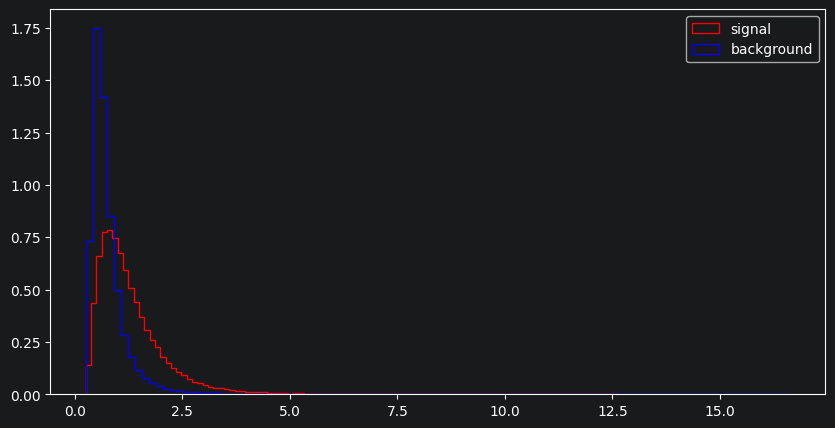

l_1_eta


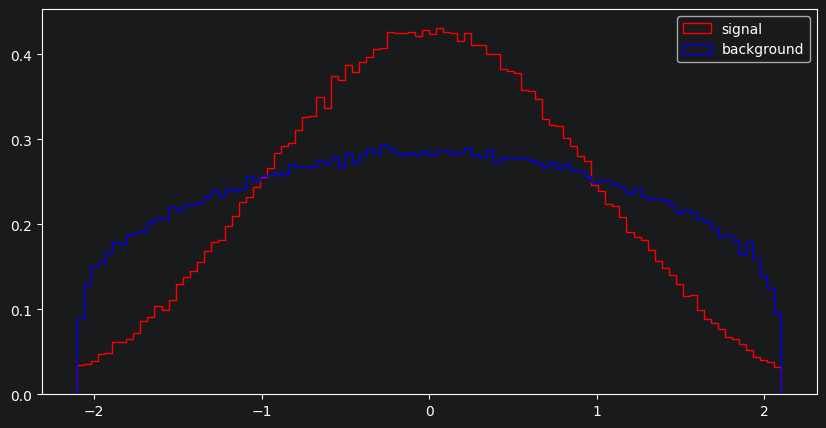

l_1_phi


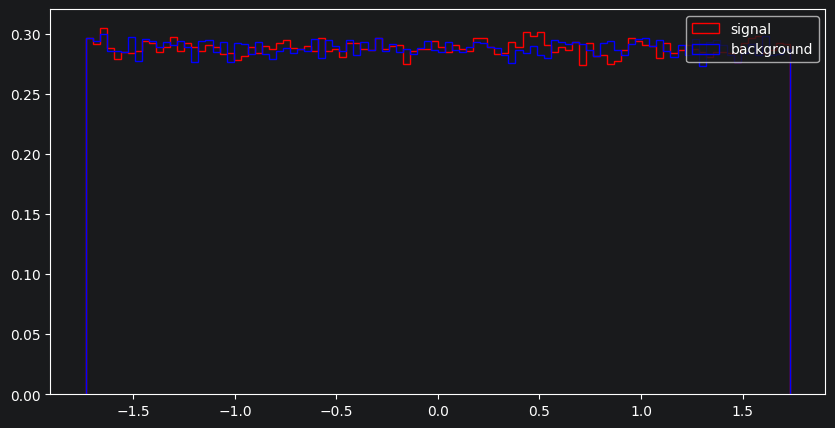

l_2_pT


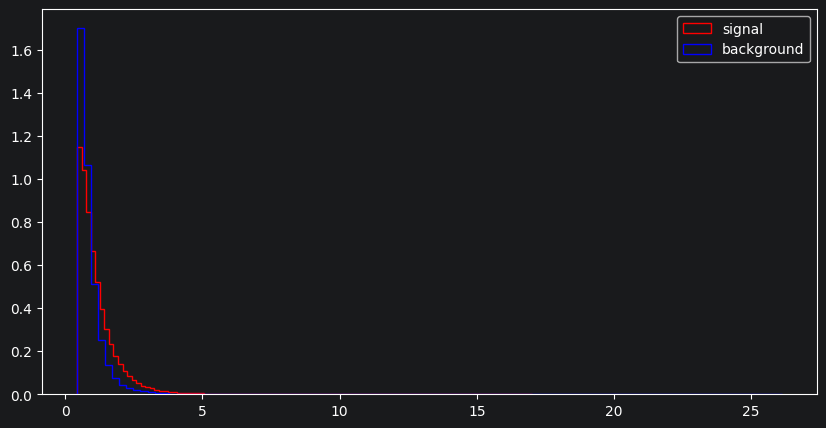

l_2_eta


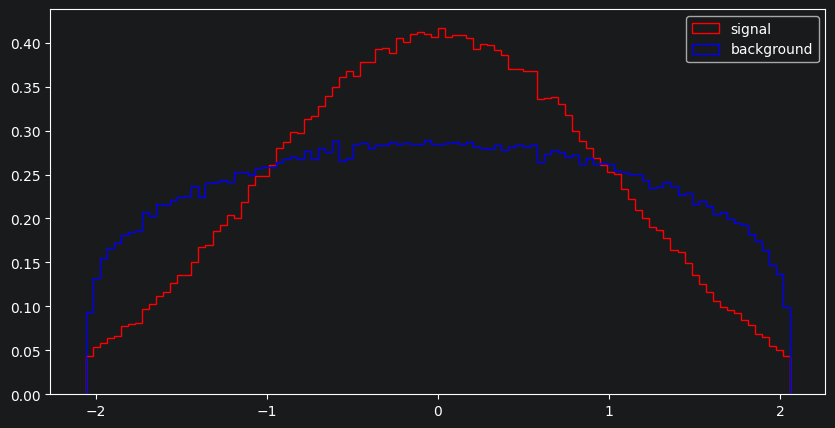

l_2_phi


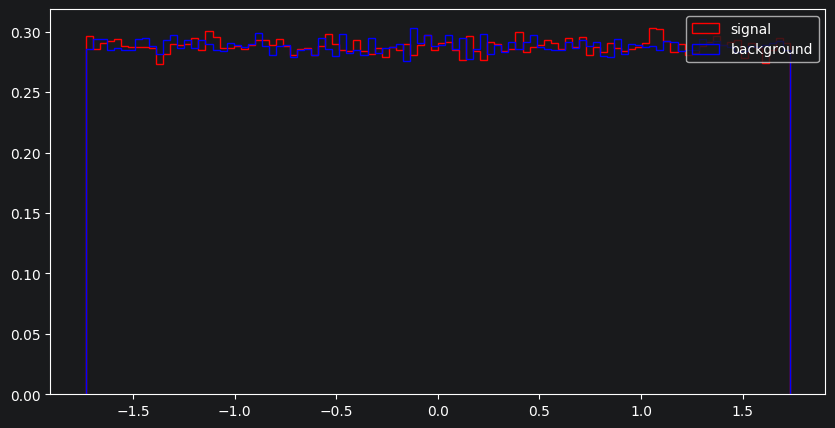

MET


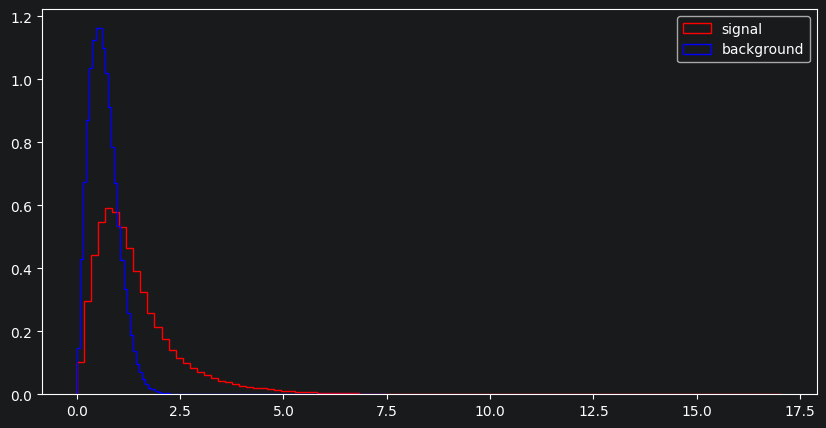

MET_phi


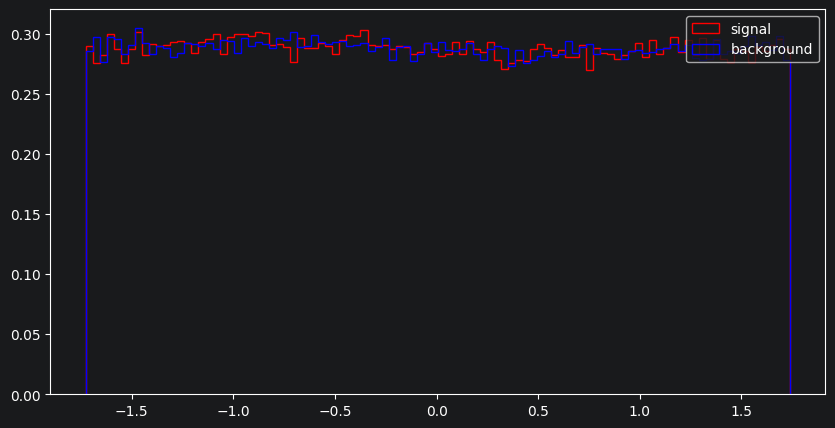

MET_rel


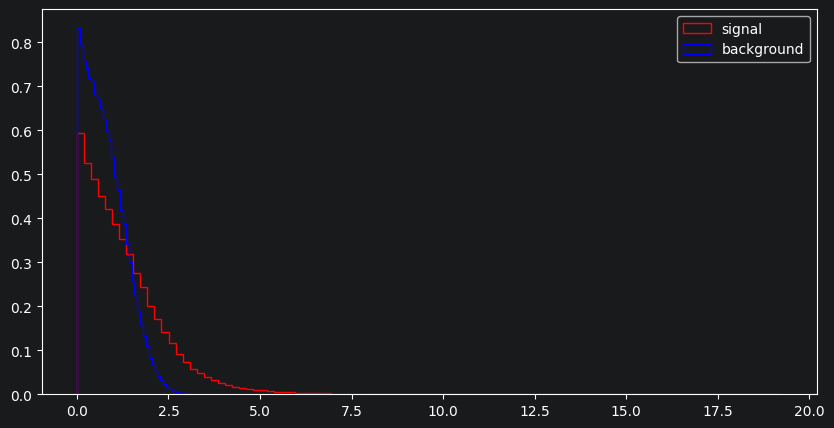

axial_MET


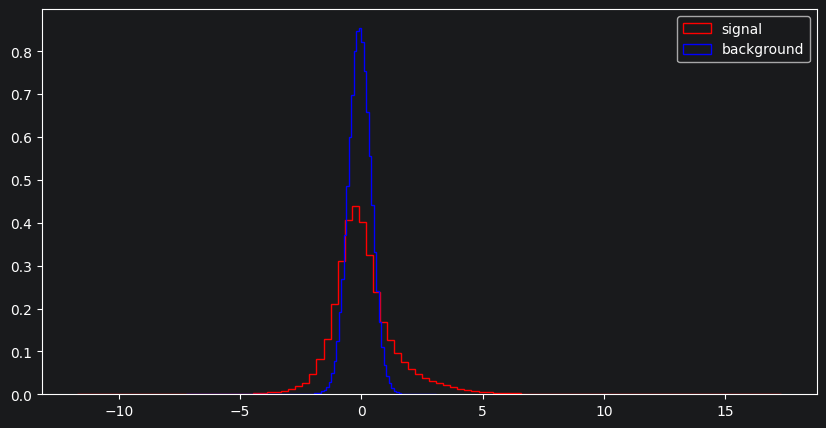

M_R


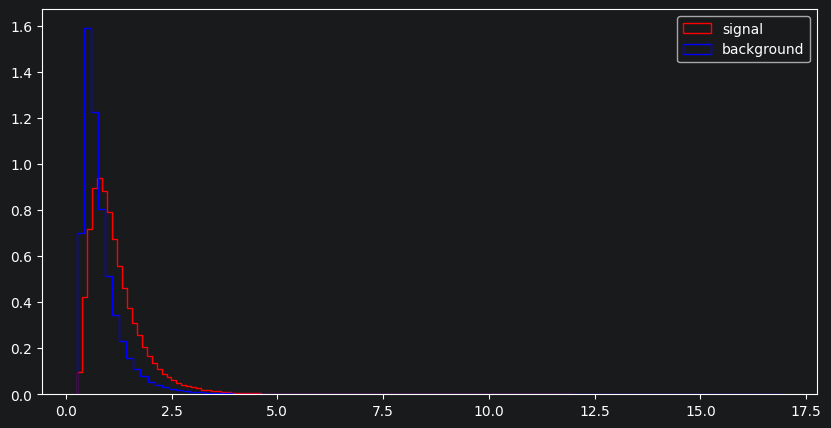

M_TR_2


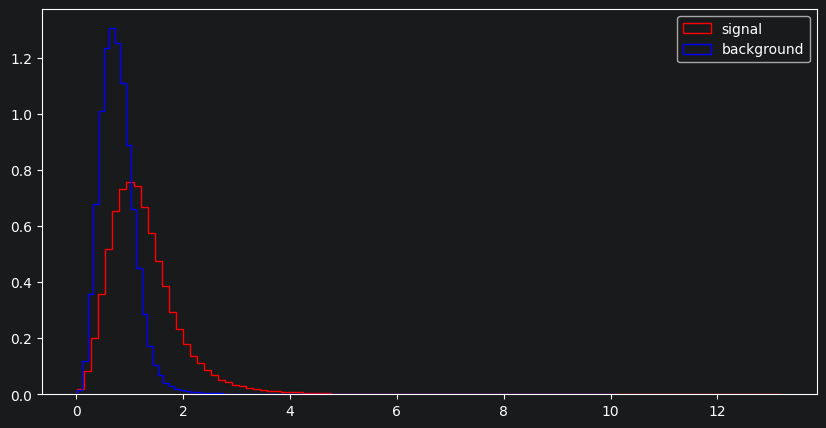

R


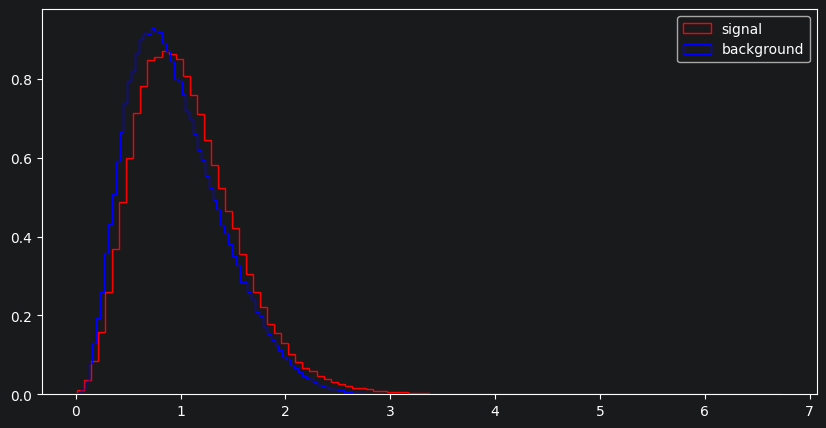

MT2


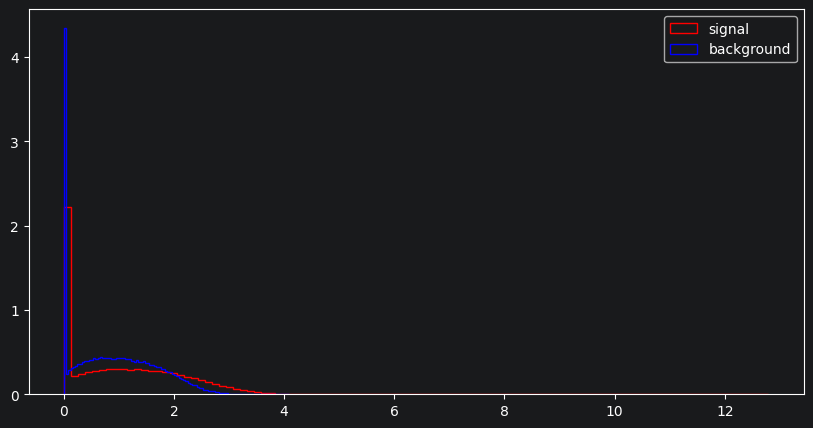

S_R


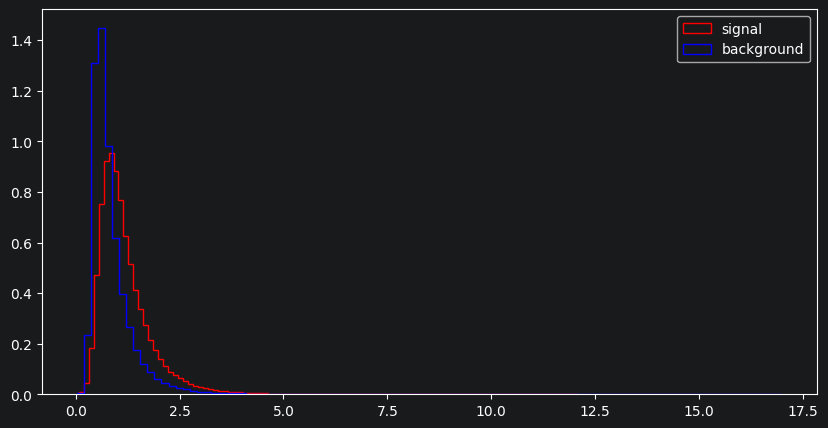

M_Delta_R


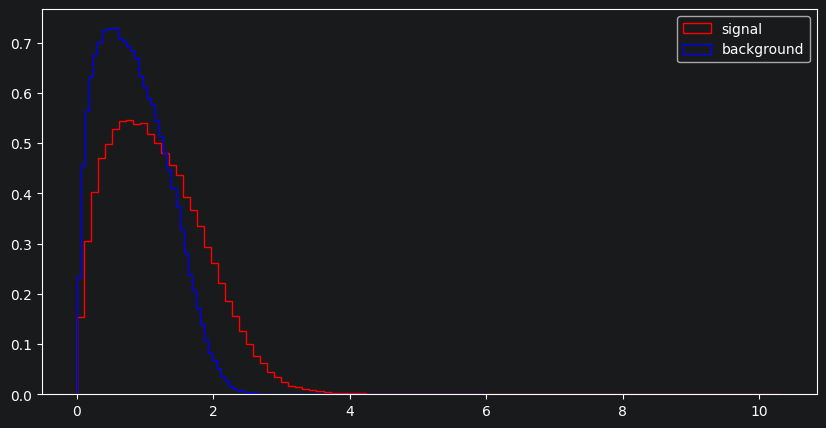

dPhi_r_b


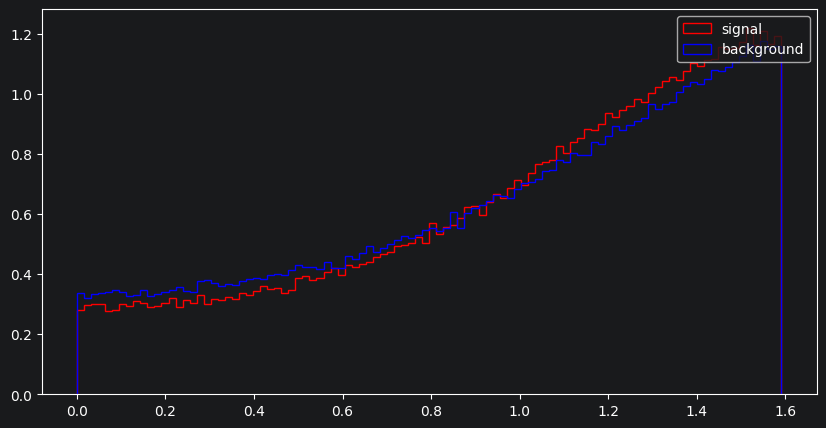

cos_theta_r1


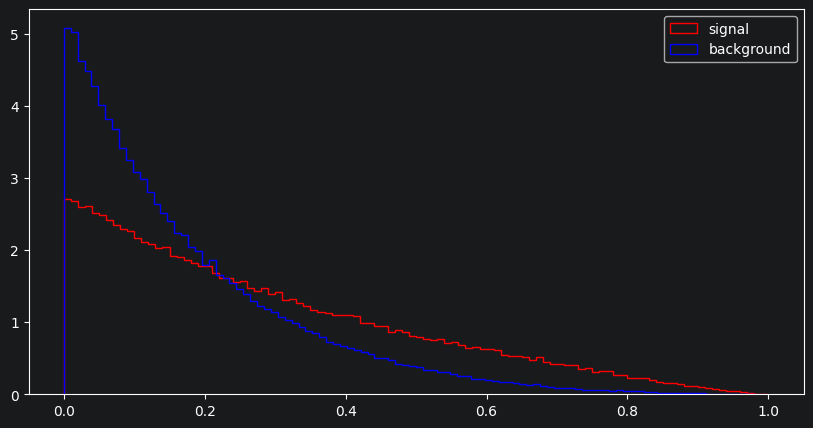

In [14]:
for var in VarNames[1:]: # histogram for all features (no label)
  print(var)
  plt.figure(figsize=(10,5))
  plt.hist(np.array(df_sig[var]),bins=100, histtype="step",color="red",label="signal", density=1, stacked=True)
  plt.hist(np.array(df_bkg[var]),bins=100, histtype="step",color="blue",label="background", density=1, stacked=True)
  plt.legend(loc="upper right")
  plt.show()

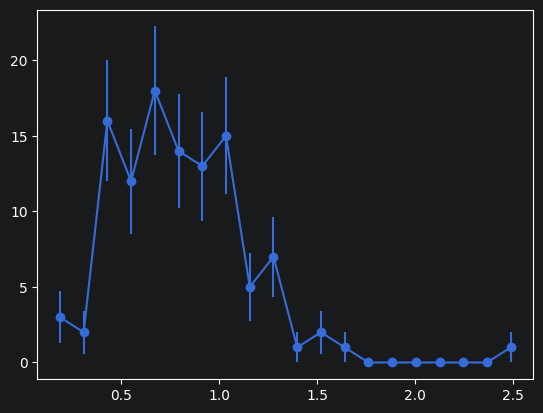

In [15]:
import math
n_bkg_expected=100
n_sig_expected=10

#mix signal and background events:
data=df_sig[:n_sig_expected]["M_TR_2"].tolist()+df_bkg[:n_bkg_expected]["M_TR_2"].tolist()

c, bin_edges=np.histogram(data,bins=20)

#each bin follows Poisson statistics, so its uncertainty is approximately the squre root of the count.
error=np.sqrt(c)

bin_width=bin_edges[1]-bin_edges[0]
bin_centers=0.5*(bin_edges[1:]+bin_edges[:-1])

plt.errorbar(bin_centers, c,yerr=error, marker="o" )
plt.show()

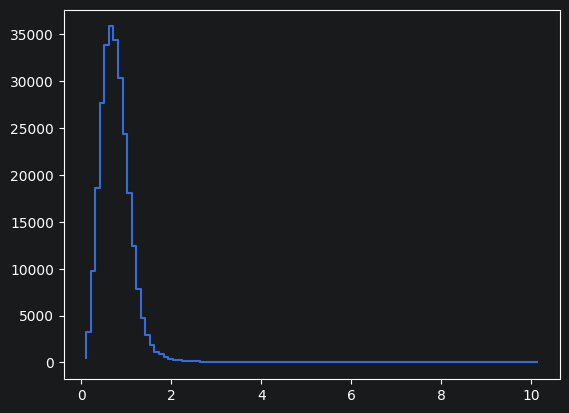

In [16]:
# background Histogram
c_bkg_sim, sim_bin= np.histogram(df_bkg["M_TR_2"],bins=100)
plt.step(sim_bin[1:],c_bkg_sim)

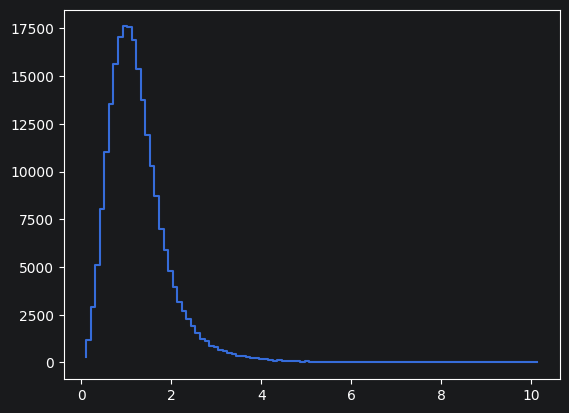

In [17]:
# signal Histogram
c_sig_sim, sim_bin= np.histogram(df_sig["M_TR_2"],bins=sim_bin)
plt.step(sim_bin[1:],c_sig_sim)

Bin size: 0.10117358507588506
Integral: 270755
N Bkg Expected: 100
Nornalized Integral: 100.0000000000001


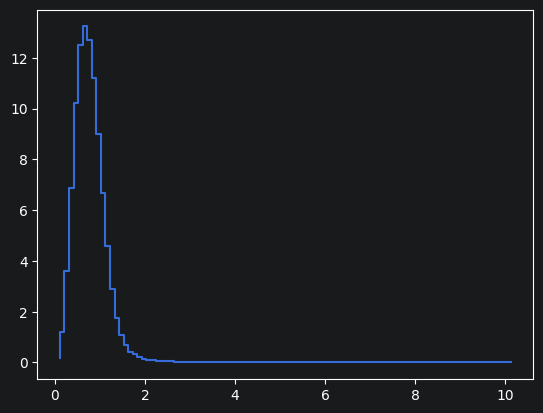

In [18]:
#Compute the bin size:
bin_size_sim=sim_bin[1]-sim_bin[0]
print("Bin size:", bin_size_sim)

#Compute the integral:
integral=sum(c_bkg_sim)
print("Integral:", integral)
print("N Bkg Expected:", n_bkg_expected)

#Divide the counts by integral and multiply by expected number:
c_bkg_sim_normalized=(n_bkg_expected/integral)*c_bkg_sim
plt.step(sim_bin[1:],c_bkg_sim_normalized)
print("Nornalized Integral:", sum(c_bkg_sim_normalized))

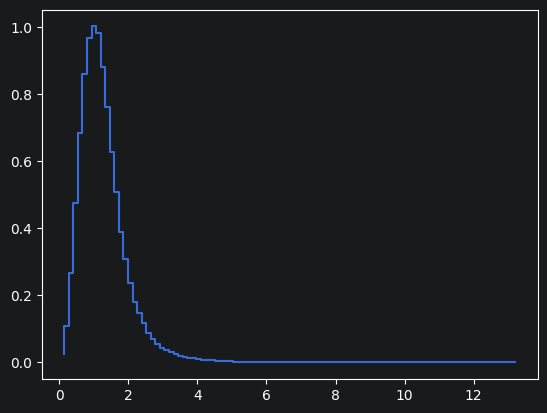

In [19]:
c_sig_sim,sim_bin=np.histogram(df_sig["M_TR_2"],bins=100)
integral=sum(c_sig_sim)
c_sig_sim_normalized=(n_sig_expected/integral)*c_sig_sim
plt.step(sim_bin[1:],c_sig_sim_normalized)

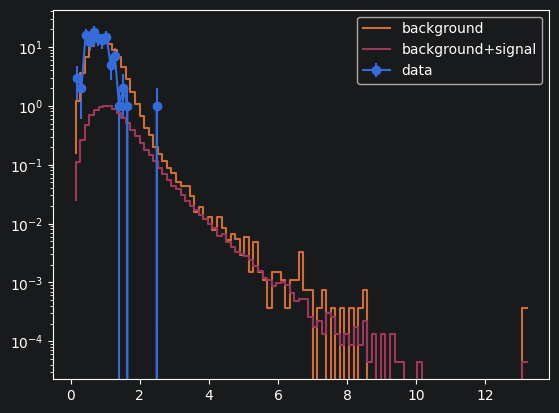

In [20]:
#Pseudo-data compared to expected simulation templates for background and signal

plt.errorbar(bin_centers,c,yerr=error, marker="o", label="data")
plt.yscale("log") # emphasizes differences in both low- and hight- statistic bins
plt.step(sim_bin[1:],c_bkg_sim_normalized, label="background")
plt.step(sim_bin[1:],c_sig_sim_normalized, label="background+signal")
plt.legend()
plt.show()

## Calculate TPR/FPR
### TPR: True Positive Rate
### FPR: False Positive Rate

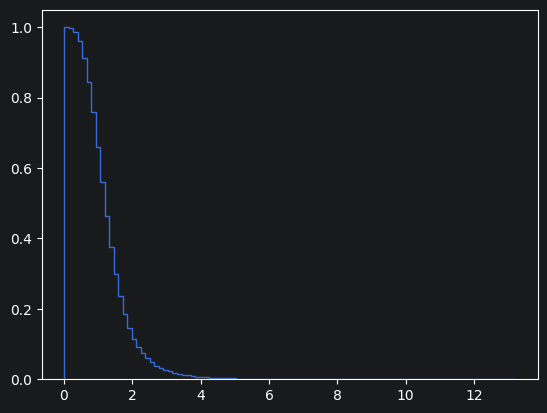

In [21]:
TPR, bins_sig, _=plt.hist(df_sig["M_TR_2"],bins=100, histtype="step", cumulative=-1, density=True)

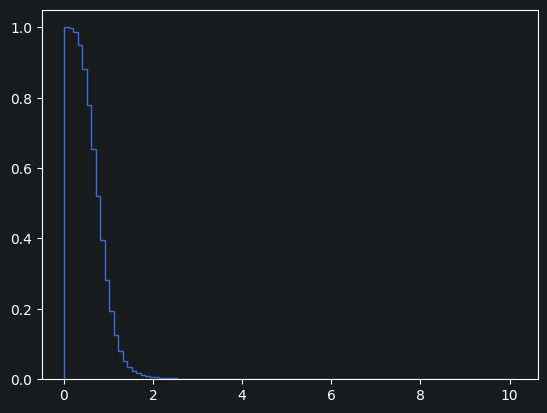

In [22]:
FPR,bins_sig,_=plt.hist(df_bkg["M_TR_2"],bins=100, histtype="step", cumulative=-1, density=True)